<a href="https://colab.research.google.com/github/Sameh184/Diabetes_repo/blob/main/Diabetes_Prediction_Model_GNB_Class_Weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Reading the data and inspecting it
import pandas as pd
dataset = pd.read_csv('/content/Diabetes Dataset (1).csv')
print(dataset.head())
print(dataset.info())
print(dataset.describe())
print(dataset['CLASS'].value_counts())
print(dataset['Gender'].value_counts())



#Gender needs to be encoded along with the target variable.


#The Yes values in the data set are way more than the no and the P meaning that we have about an 80-20 imbalance of data which could cause the model to be biased.

    ID  No_Pation Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL  \
0  502      17975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
1  735      34221      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6   
2  420      47975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
3  680      87656      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
4  504      34223      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4   

    BMI CLASS  
0  24.0     N  
1  23.0     N  
2  24.0     N  
3  24.0     N  
4  21.0     N  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c     

In [3]:
#Data cleaning

dataset["CLASS"] = dataset["CLASS"].replace("Y " , "Y")
dataset["CLASS"] = dataset["CLASS"].replace("N " , "N")
dataset["Gender"] = dataset["Gender"].replace("f" , "F")
print(dataset['CLASS'].value_counts())
print(dataset['Gender'].value_counts())


#Removing useless columns
dataset = dataset.drop(axis= 1 , columns=["ID" , "No_Pation" ])

print(dataset.head())
print(dataset.shape)

#Checking if there are any missing values
print(dataset.isna().sum())


CLASS
Y    844
N    103
P     53
Name: count, dtype: int64
Gender
M    565
F    435
Name: count, dtype: int64
  Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI CLASS
0      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
1      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0     N
2      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
3      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
4      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0     N
(1000, 12)
Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [4]:
print("--- Outlier Report ---")

numerical_columns_to_check = ["AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]

cleaned_dataset = dataset.copy()

for col in numerical_columns_to_check:
    Q1 = cleaned_dataset[col].quantile(0.25)
    Q3 = cleaned_dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers_low = (cleaned_dataset[col] < lower_bound).sum()
    outliers_high = (cleaned_dataset[col] > upper_bound).sum()
    total_outliers = outliers_low + outliers_high

    print(f"Column: {col}")
    print(f"  Bounds:    [{lower_bound:.2f} , {upper_bound:.2f}]")
    print(f"  Outliers:  {total_outliers} (Low: {outliers_low}, High: {outliers_high})\n")
    # removing outliers
    dataset = cleaned_dataset[
        (cleaned_dataset[col] >= lower_bound) &
        (cleaned_dataset[col] <= upper_bound)
    ]
    # FIX: carry the filtered rows forward so outlier removal accumulates
    # across columns instead of only reflecting the last column processed.
    cleaned_dataset = dataset.copy()

print(f"Final dataset shape after cumulative outlier removal: {dataset.shape}")

--- Outlier Report ---
Column: AGE
  Bounds:    [39.00 , 71.00]
  Outliers:  98 (Low: 79, High: 19)

Column: Urea
  Bounds:    [0.70 , 8.70]
  Outliers:  59 (Low: 1, High: 58)

Column: Cr
  Bounds:    [8.50 , 108.50]
  Outliers:  10 (Low: 0, High: 10)

Column: HbA1c
  Bounds:    [1.55 , 15.55]
  Outliers:  6 (Low: 4, High: 2)

Column: Chol
  Bounds:    [1.60 , 8.00]
  Outliers:  24 (Low: 3, High: 21)

Column: TG
  Bounds:    [-0.60 , 5.00]
  Outliers:  40 (Low: 0, High: 40)

Column: HDL
  Bounds:    [0.30 , 1.90]
  Outliers:  40 (Low: 1, High: 39)

Column: LDL
  Bounds:    [-0.45 , 5.55]
  Outliers:  3 (Low: 0, High: 3)

Column: VLDL
  Bounds:    [-0.35 , 2.45]
  Outliers:  42 (Low: 0, High: 42)

Column: BMI
  Bounds:    [15.50 , 43.50]
  Outliers:  0 (Low: 0, High: 0)

Final dataset shape after cumulative outlier removal: (678, 12)


In [5]:
#Feature transformation
dataset['CLASS'] = dataset['CLASS'].astype('category').cat.codes
dataset['Gender'] = dataset['Gender'].astype('category').cat.codes


dataset.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
5,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
6,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0
7,1,48,4.7,47,4.0,2.9,0.8,0.9,1.6,0.4,24.0,0
13,0,45,4.6,54,5.1,4.2,1.7,1.2,2.2,0.8,23.0,0
14,0,50,3.5,39,4.0,4.0,1.5,1.2,2.2,0.7,24.0,0


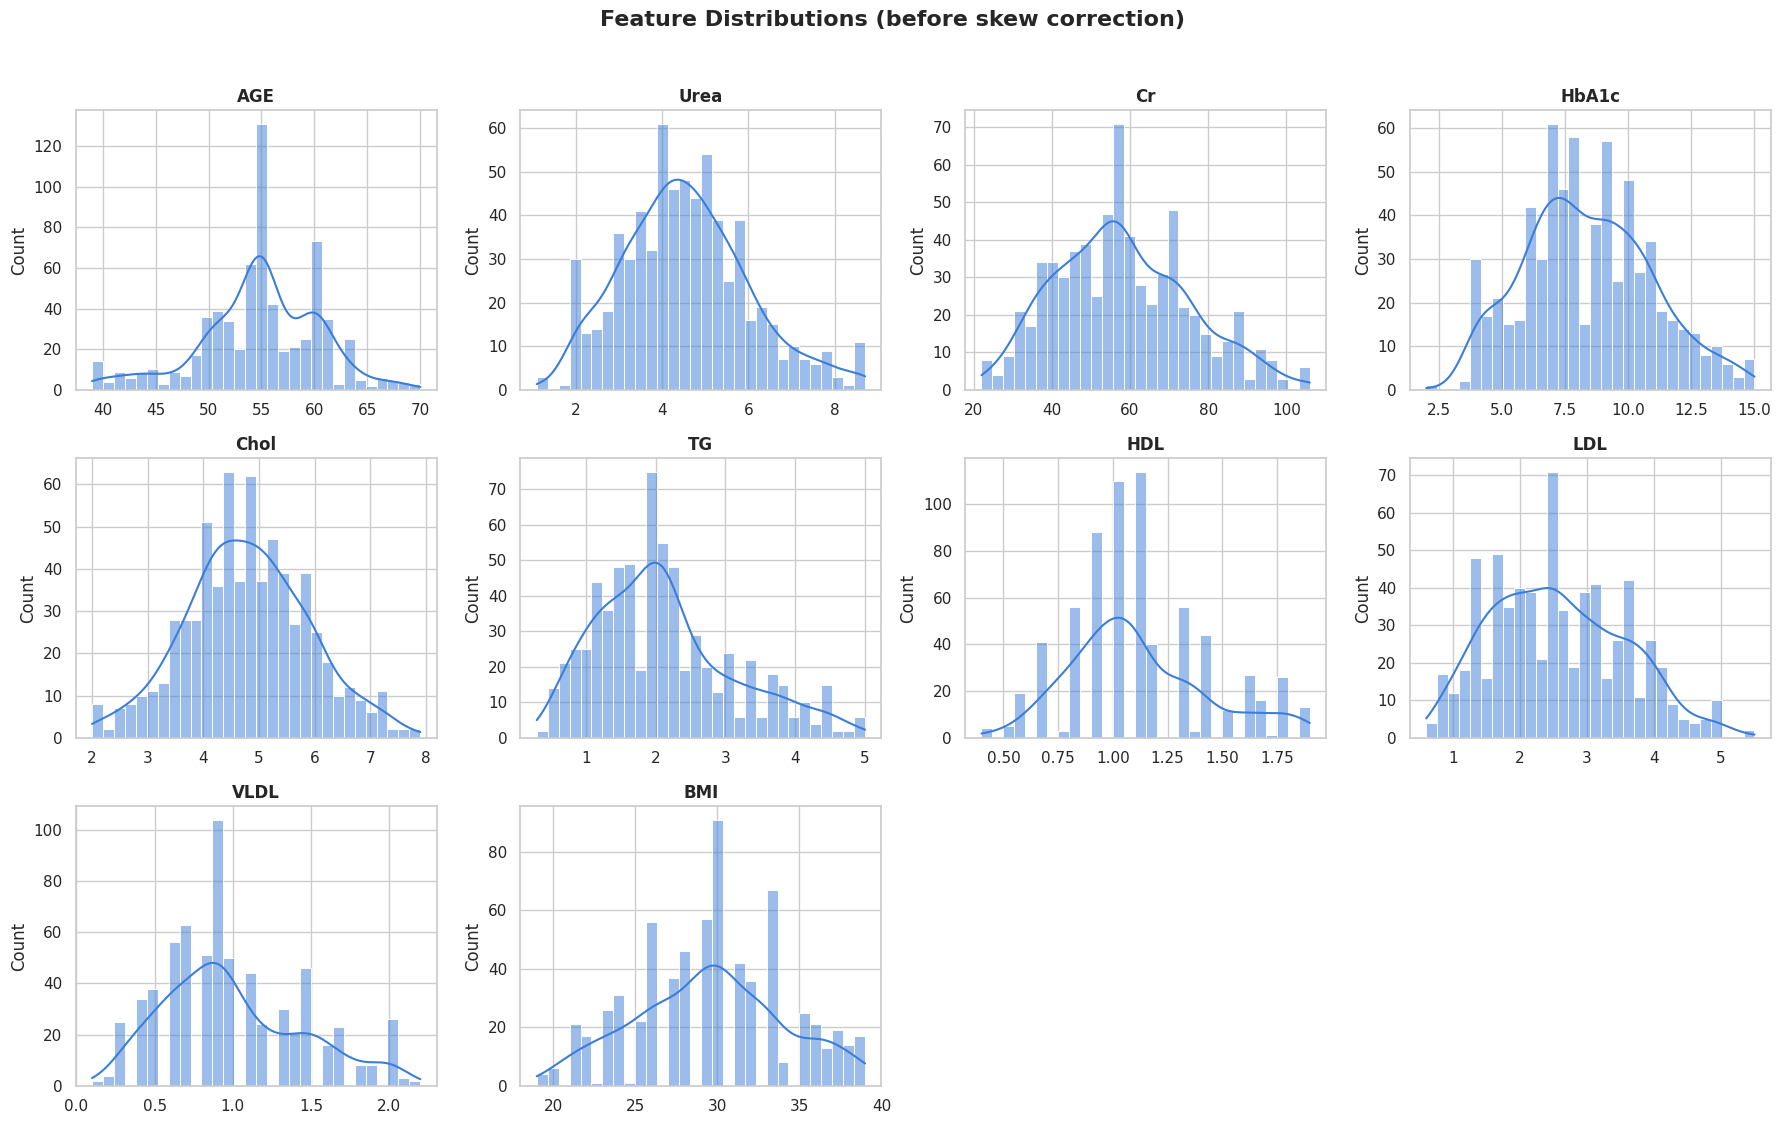

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [6]:
#Plot histograms to show skewness
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")

numerical_columns = dataset.select_dtypes(exclude="object")
numerical_columns = numerical_columns.drop(axis=1 , columns=["Gender" , "CLASS"])

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, col in zip(axes, numerical_columns.columns):
    sns.histplot(numerical_columns[col], bins=30, kde=True, color="#3b7dd8", ax=ax, edgecolor="white")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
for ax in axes[len(numerical_columns.columns):]:
    ax.axis("off")
fig.suptitle("Feature Distributions (before skew correction)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(dataset.isna().sum())

#The following columns are skewed => Urea , Cr , TG , VLDL , HDL , LDL

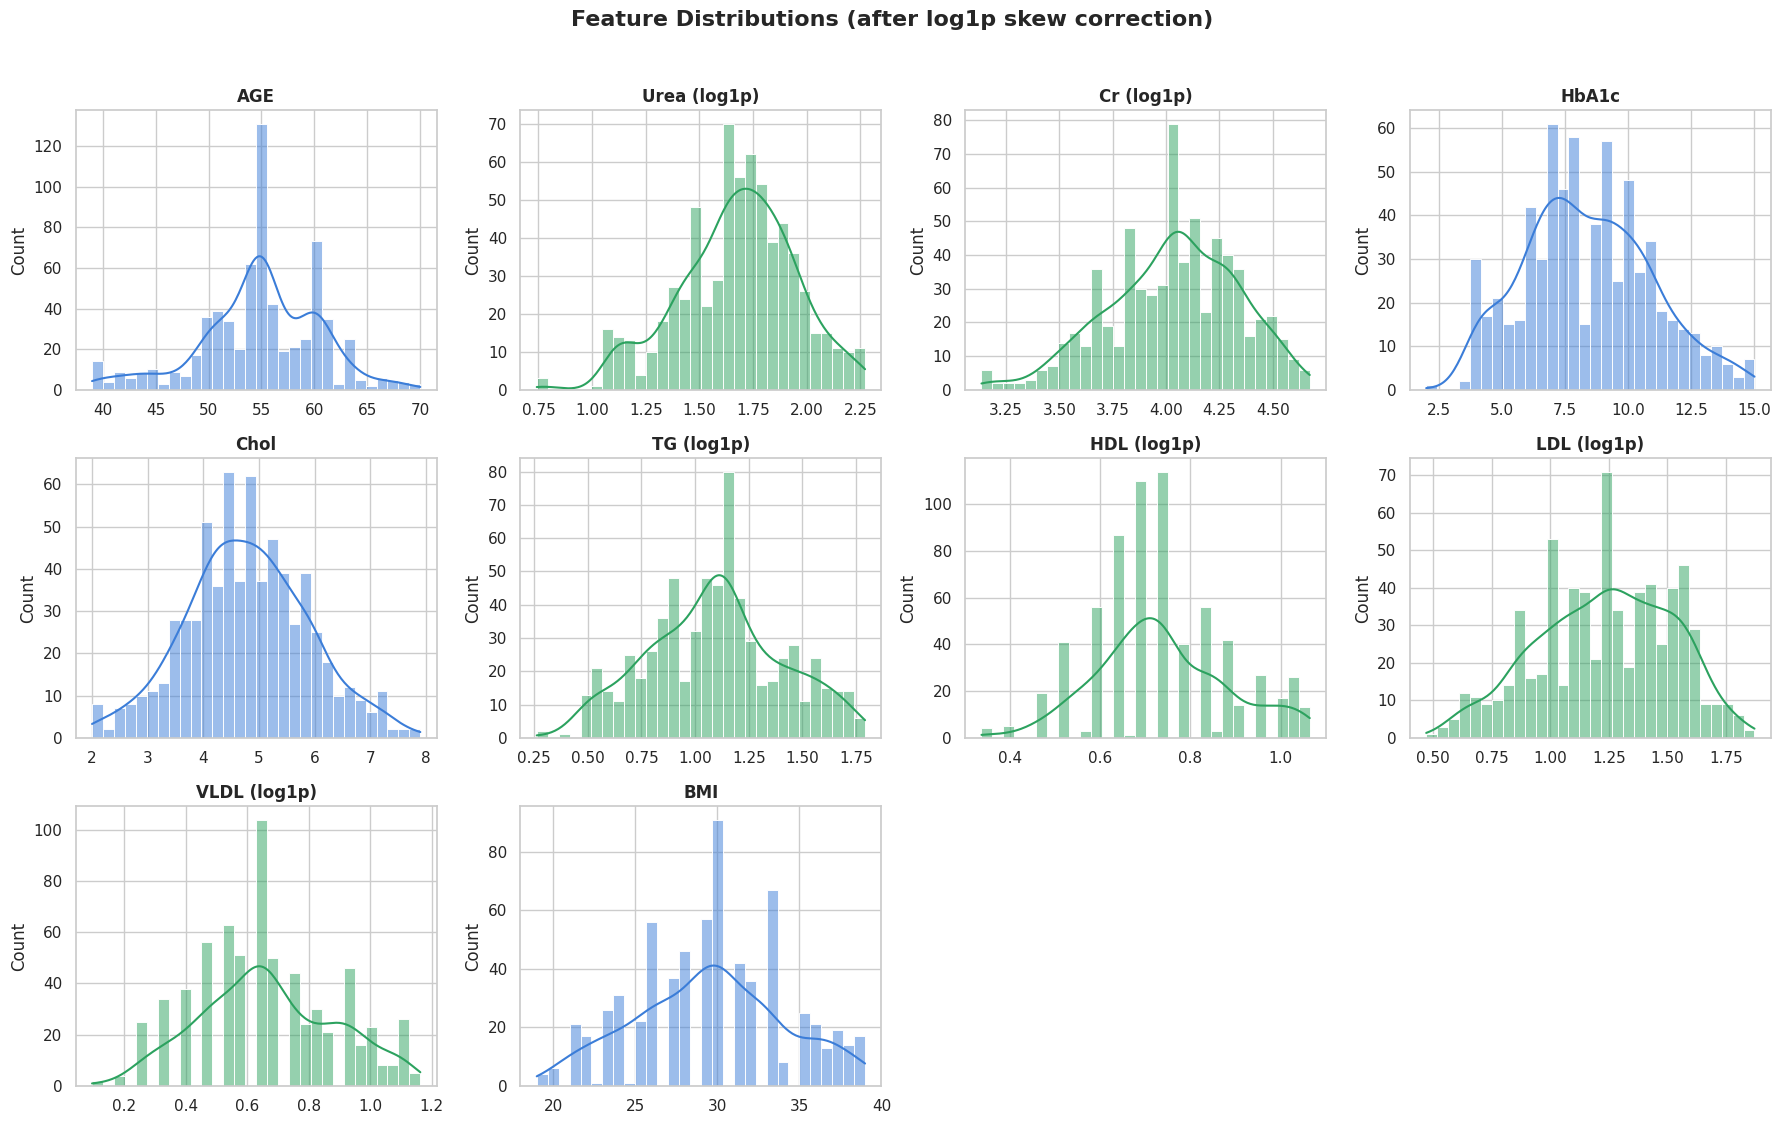

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [7]:
# # Fixing skewness
import numpy as np

skewed_columns = [ "VLDL" , "HDL" , "Urea", "Cr" , "LDL" , "TG"]
for column in skewed_columns:
    dataset[column] = np.log1p(dataset[column])
numerical_columns = dataset.select_dtypes(exclude="object")
numerical_columns = numerical_columns.drop(axis=1 , columns=["Gender" , "CLASS"])

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, col in zip(axes, numerical_columns.columns):
    is_transformed = col in skewed_columns
    color = "#2ca25f" if is_transformed else "#3b7dd8"
    sns.histplot(numerical_columns[col], bins=30, kde=True, color=color, ax=ax, edgecolor="white")
    ax.set_title(col + (" (log1p)" if is_transformed else ""), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
for ax in axes[len(numerical_columns.columns):]:
    ax.axis("off")
fig.suptitle("Feature Distributions (after log1p skew correction)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(dataset.isna().sum())

In [8]:
dataset.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
5,0,45,1.193922,3.218876,4.0,2.9,0.693147,0.693147,0.916291,0.336472,21.0,0
6,0,50,1.098612,3.931826,4.0,3.6,0.832909,0.641854,1.131402,0.470004,24.0,0
7,1,48,1.740466,3.871201,4.0,2.9,0.587787,0.641854,0.955511,0.336472,24.0,0
13,0,45,1.722767,4.007333,5.1,4.2,0.993252,0.788457,1.163151,0.587787,23.0,0
14,0,50,1.504077,3.688879,4.0,4.0,0.916291,0.788457,1.163151,0.530628,24.0,0


In [9]:
#Divide our data into 3 groups
from scipy.stats import f_oneway

group_Y = dataset[dataset["CLASS"] == 1]
group_N = dataset[dataset["CLASS"] == 0]
group_P = dataset[dataset["CLASS"] == 2]
anovaColumns = ["AGE" , "Urea" , "Cr" , "HbA1c" ,"Chol" , "TG" , "HDL" , "LDL" , "VLDL" , "BMI" , "Gender"]
for column in anovaColumns:
    f_statistic, p_value = f_oneway(group_N[column] , group_P[column] , group_Y[column])
    print(f"Column : {column} , p_value : {p_value}")

#Any value lower than 0.05 means that this column can be used very well to diffrentiate between different target values => AGE , HbA1c , Chol , TG , VLDL , BMI, Urea ,Gender

Column : AGE , p_value : 7.577513666397487e-51
Column : Urea , p_value : 0.42528287538455734
Column : Cr , p_value : 0.6296991977575055
Column : HbA1c , p_value : 7.923968747656728e-47
Column : Chol , p_value : 0.00018709797229422926
Column : TG , p_value : 2.8951399027271677e-09
Column : HDL , p_value : 0.41218444625499007
Column : LDL , p_value : 0.3910836031248651
Column : VLDL , p_value : 7.391454000338725e-06
Column : BMI , p_value : 3.642215933896432e-58
Column : Gender , p_value : 0.008258291092678291


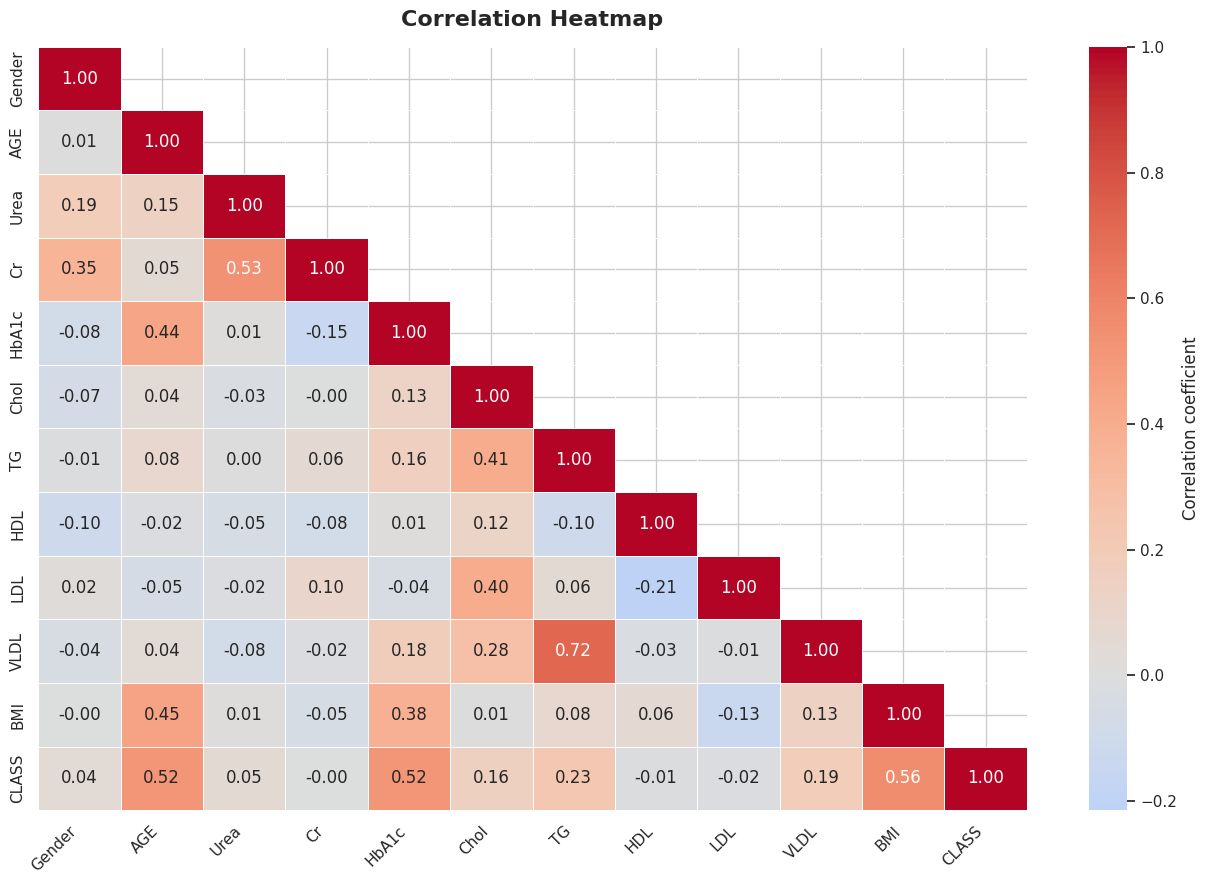

In [10]:
import seaborn as sns
import numpy as np

corr = dataset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation coefficient"}
)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#Plotting the heatmap to display correlations and see if there is any multicolinearity
#Urea => CR

In [11]:
# Train-test split for Gaussian Naive Bayes
# This uses the phase-1 cleaned and log-transformed dataset before binning.
from sklearn.model_selection import train_test_split

X = dataset.drop(columns="CLASS")
y = dataset["CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts())
print("Test class distribution:")
print(y_test.value_counts())

Train shape: (474, 11)
Test shape: (204, 11)
Train class distribution:
CLASS
2    410
0     39
1     25
Name: count, dtype: int64
Test class distribution:
CLASS
2    176
0     17
1     11
Name: count, dtype: int64


In [12]:
# Gaussian Naive Bayes Version 2: PowerTransformer + GaussianNB with class-balanced sample weights
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import PowerTransformer
from sklearn.utils import compute_class_weight

target_labels = [0, 1, 2]
target_names = ["Normal", "Pre-Diabetes", "Diabetes"]

model = ImbPipeline([
    ("transform", PowerTransformer(method="yeo-johnson")),
    ("nb", GaussianNB()),
])

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weight_dict[label] for label in y_train])

print("Class weights:", class_weight_dict)

model.fit(X_train, y_train, nb__sample_weight=sample_weights)

print("\n--- TRAINING PERFORMANCE ---")
y_pred_train = model.predict(X_train)
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print(
    classification_report(
        y_train,
        y_pred_train,
        labels=target_labels,
        target_names=target_names,
        zero_division=0,
    )
)
print(confusion_matrix(y_train, y_pred_train, labels=target_labels))

print("\n--- TESTING PERFORMANCE ---")
y_pred_test = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print(
    classification_report(
        y_test,
        y_pred_test,
        labels=target_labels,
        target_names=target_names,
        zero_division=0,
    )
)
print(confusion_matrix(y_test, y_pred_test, labels=target_labels))

Class weights: {np.int8(0): np.float64(4.051282051282051), np.int8(1): np.float64(6.32), np.int8(2): np.float64(0.3853658536585366)}

--- TRAINING PERFORMANCE ---
Accuracy: 0.959915611814346
              precision    recall  f1-score   support

      Normal       0.68      1.00      0.81        39
Pre-Diabetes       0.96      0.96      0.96        25
    Diabetes       1.00      0.96      0.98       410

    accuracy                           0.96       474
   macro avg       0.88      0.97      0.92       474
weighted avg       0.97      0.96      0.96       474

[[ 39   0   0]
 [  1  24   0]
 [ 17   1 392]]

--- TESTING PERFORMANCE ---
Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

      Normal       0.77      1.00      0.87        17
Pre-Diabetes       1.00      0.82      0.90        11
    Diabetes       0.99      0.98      0.99       176

    accuracy                           0.97       204
   macro avg       0.92      0.93      0.92       20

In [13]:
print("\n--- CROSS VALIDATION ---")
print("Note: cross_val_score evaluates the same transformer + GaussianNB pipeline without manually passed sample weights.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_acc = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
scores_f1 = cross_val_score(model, X, y, cv=cv, scoring="f1_weighted")

print("CV Accuracies:", scores_acc)
print("Mean Accuracy:", scores_acc.mean())
print("Mean F1:", scores_f1.mean())


--- CROSS VALIDATION ---
Note: cross_val_score evaluates the same transformer + GaussianNB pipeline without manually passed sample weights.
CV Accuracies: [0.94852941 0.94852941 0.94117647 0.95555556 0.98518519]
Mean Accuracy: 0.9557952069716775
Mean F1: 0.9577108295570562
